# 09 — Final Held-Out Test

## Objective

Perform the final evaluation of the forecasting system on the completely
untouched December 2018 test period.

All development decisions have already been completed using January–November:

- forecasting formulation;
- feature engineering;
- model-family comparison;
- feature-group comparison;
- hyperparameter tuning.

The final selected model is tuned XGBoost using:

- historical energy features;
- calendar features;
- load type.

The final model will be trained once on all available January–November
development data and evaluated once on December.

No model, feature, or hyperparameter changes will be made based on the
December results.

Primary metric:

**Mean Absolute Error (MAE)**

The final model will also be compared against the 15-minute persistence
forecast.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [2]:
#Load the gold table
con = duckdb.connect(
    "Steel_energy.duckdb"
)

df = con.sql("""
SELECT *
FROM gold_energy_features
ORDER BY timestamp
""").df()

df = df.sort_values(
    "timestamp"
).reset_index(drop=True)

df.head()

,timestamp,usage_kwh,hour,month,day_of_week,week_status,load_type,usage_15min_ago,usage_1h_ago,usage_lag_96,avg_usage_previous_hour
0,2018-01-01 00:00:00,3.42,0,1,Monday,Weekday,Light_Load,NaN,NaN,NaN,NaN
1,2018-01-01 00:15:00,3.17,0,1,Monday,Weekday,Light_Load,3.42,NaN,NaN,3.4200
2,2018-01-01 00:30:00,4.00,0,1,Monday,Weekday,Light_Load,3.17,NaN,NaN,3.2950
3,2018-01-01 00:45:00,3.24,0,1,Monday,Weekday,Light_Load,4.00,NaN,NaN,3.5300
4,2018-01-01 01:00:00,3.31,1,1,Monday,Weekday,Light_Load,3.24,3.42,NaN,3.4575


In [3]:
#Verify time coverage
df["timestamp"].min(), df["timestamp"].max()

(Timestamp('2018-01-01 00:00:00'), Timestamp('2018-12-31 23:45:00'))

In [4]:
#define the feature set
numeric_features = [
    "usage_15min_ago",
    "usage_1h_ago",
    "usage_lag_96",
    "avg_usage_previous_hour",
    "hour",
    "month"
]

categorical_features = [
    "day_of_week",
    "week_status",
    "load_type"
]

feature_columns = (
    numeric_features
    +
    categorical_features
)

target = "usage_kwh"

In [5]:
#Open december 
development_df = df[
    df["timestamp"] < "2018-12-01"
].copy()

test_df = df[
    df["timestamp"] >= "2018-12-01"
].copy()

In [6]:
#verify temporal split
print(
    "Development:",
    development_df["timestamp"].min(),
    "to",
    development_df["timestamp"].max()
)

print(
    "Final test:",
    test_df["timestamp"].min(),
    "to",
    test_df["timestamp"].max()
)

Development: 2018-01-01 00:00:00 to 2018-11-30 23:45:00
Final test: 2018-12-01 00:00:00 to 2018-12-31 23:45:00


In [7]:
#Remove NULL rows
train_df = development_df.dropna(
    subset=feature_columns + [target]
).copy()

final_test_df = test_df.dropna(
    subset=feature_columns + [target]
).copy()

print(
    "Training rows:",
    len(train_df)
)

print(
    "Final test rows:",
    len(final_test_df)
)

Training rows: 31968
Final test rows: 2976


In [8]:
#leakage/split sanity checks
assert (
    train_df["timestamp"].max()
    <
    final_test_df["timestamp"].min()
)

assert (
    final_test_df["timestamp"].min()
    >=
    pd.Timestamp("2018-12-01")
)

print(
    "Temporal split verified."
)

Temporal split verified.


In [9]:
#preprocessing definition
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [10]:
#Freezing the selected hyperparameters
final_xgb_params = {
    "subsample": 0.85,
    "reg_lambda": 1,
    "reg_alpha": 1.0,
    "n_estimators": 600,
    "max_depth": 7,
    "learning_rate": 0.01,
    "colsample_bytree": 1.0
}

final_xgb_params

{'subsample': 0.85,
 'reg_lambda': 1,
 'reg_alpha': 1.0,
 'n_estimators': 600,
 'max_depth': 7,
 'learning_rate': 0.01,
 'colsample_bytree': 1.0}

In [11]:
#Building final pipeline
final_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            **final_xgb_params
        )
    )
])

final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [12]:
#definig train/test data
X_train = train_df[
    feature_columns
]

y_train = train_df[
    target
]

X_test = final_test_df[
    feature_columns
]

y_test = final_test_df[
    target
]

In [13]:
#Final model training
final_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['usage_15min_ago','usage_1h_ago','usage_lag_96',...,'day_of_week', 'week_status','load_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. T

In [14]:
#predict december
final_predictions = final_model.predict(
    X_test
)

final_predictions[:10]

array([4.0811696, 3.6321542, 4.085197 , 4.085197 , 3.799155 , 3.9407146,
       3.9985468, 3.808717 , 3.8391645, 3.8614266], dtype=float32)

In [15]:
#metric function
def evaluate_forecast(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [16]:
#final test metrics
final_model_metrics = evaluate_forecast(
    y_test,
    final_predictions
)

final_model_metrics

{'MAE': 3.2365503323719067,
 'RMSE': np.float64(6.892202841145527),
 'R2': 0.9349145143114619}

In [17]:
#Persistence baselien model 
persistence_predictions = (
    final_test_df[
        "usage_15min_ago"
    ].values
)

In [18]:
#Persistence test metrics
persistence_metrics = evaluate_forecast(
    y_test,
    persistence_predictions
)

persistence_metrics

{'MAE': 3.8185618279569895,
 'RMSE': np.float64(9.612046411827103),
 'R2': 0.8734098928855288}

In [19]:
#Final table for comparison
test_results = pd.DataFrame([
    {
        "model":
            "Persistence",

        **persistence_metrics
    },

    {
        "model":
            "Tuned XGBoost",

        **final_model_metrics
    }
])

test_results

,model,MAE,RMSE,R2
0,Persistence,3.818562,9.612046,0.873410
1,Tuned XGBoost,3.236550,6.892203,0.934915


In [20]:
#Improvement over persistence
mae_improvement = (
    (
        persistence_metrics["MAE"]
        -
        final_model_metrics["MAE"]
    )
    /
    persistence_metrics["MAE"]
    *
    100
)

rmse_improvement = (
    (
        persistence_metrics["RMSE"]
        -
        final_model_metrics["RMSE"]
    )
    /
    persistence_metrics["RMSE"]
    *
    100
)

print(
    f"MAE improvement over persistence: "
    f"{mae_improvement:.2f}%"
)

print(
    f"RMSE improvement over persistence: "
    f"{rmse_improvement:.2f}%"
)

MAE improvement over persistence: 15.24%
RMSE improvement over persistence: 28.30%


#Development CV vs final test
development_metrics = {
    "MAE": 4.839999,
    "RMSE": 9.953629,
    "R2": 0.901088
}

generalization_comparison = pd.DataFrame([
    {
        "evaluation":
            "Walk-Forward Development",

        **development_metrics
    },

    {
        "evaluation":
            "December Held-Out Test",

        **final_model_metrics
    }
])

generalization_comparison

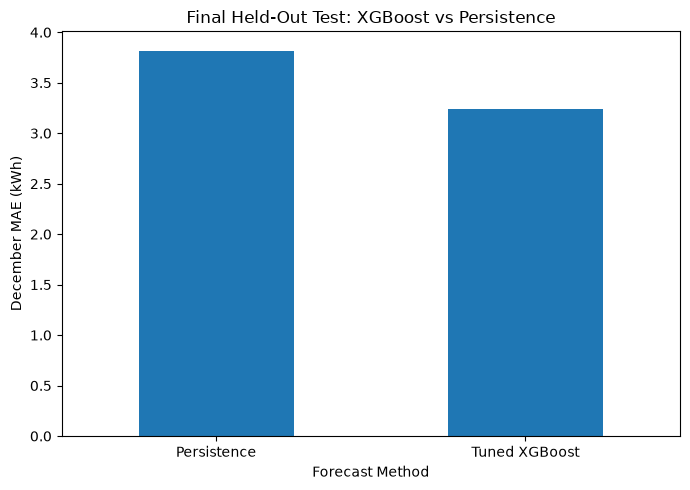

In [21]:
#Final primary metric plot
test_results.set_index(
    "model"
)["MAE"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.ylabel(
    "December MAE (kWh)"
)

plt.xlabel(
    "Forecast Method"
)

plt.title(
    "Final Held-Out Test: XGBoost vs Persistence"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [22]:
#prediction result dataframe
prediction_results = pd.DataFrame({
    "timestamp":
        final_test_df["timestamp"].values,

    "actual":
        y_test.values,

    "xgboost_prediction":
        final_predictions,

    "persistence_prediction":
        persistence_predictions
})

prediction_results[
    "xgboost_error"
] = (
    prediction_results["actual"]
    -
    prediction_results["xgboost_prediction"]
)

prediction_results[
    "absolute_error"
] = (
    prediction_results[
        "xgboost_error"
    ].abs()
)

prediction_results.head()

,timestamp,actual,xgboost_prediction,persistence_prediction,xgboost_error,absolute_error
0,2018-12-01 00:00:00,3.35,4.081170,3.82,-0.731170,0.731170
1,2018-12-01 00:15:00,3.89,3.632154,3.35,0.257846,0.257846
2,2018-12-01 00:30:00,3.85,4.085197,3.89,-0.235197,0.235197
3,2018-12-01 00:45:00,3.89,4.085197,3.85,-0.195197,0.195197
4,2018-12-01 01:00:00,3.89,3.799155,3.89,0.090845,0.090845


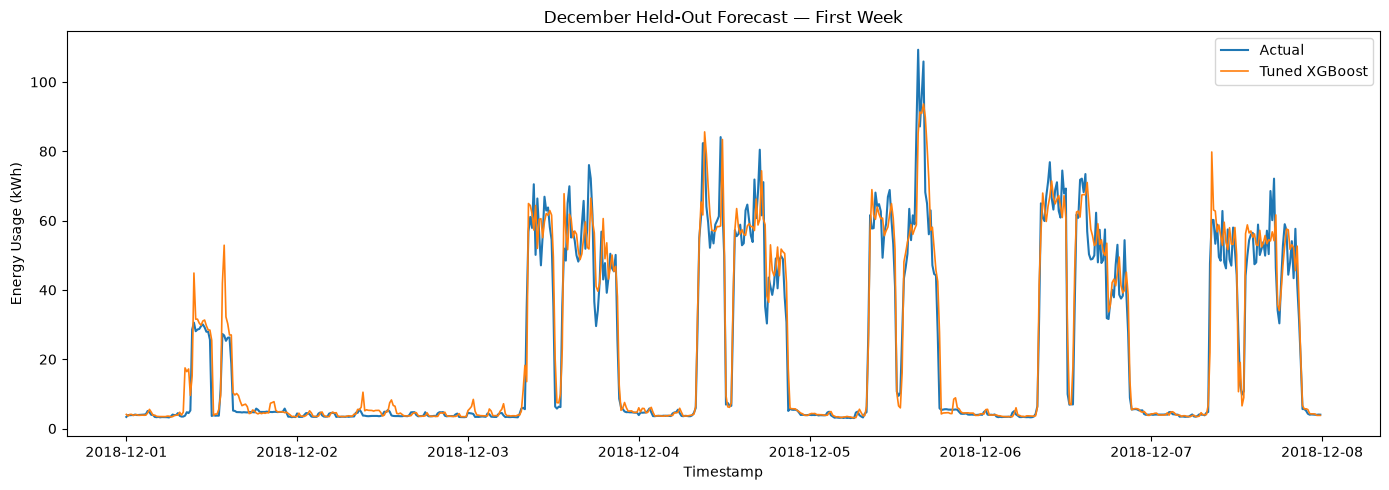

In [23]:
plot_df = prediction_results[
    prediction_results["timestamp"]
    <
    "2018-12-08"
]

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    plot_df["timestamp"],
    plot_df["actual"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    plot_df["timestamp"],
    plot_df["xgboost_prediction"],
    label="Tuned XGBoost",
    linewidth=1.2
)

plt.xlabel(
    "Timestamp"
)

plt.ylabel(
    "Energy Usage (kWh)"
)

plt.title(
    "December Held-Out Forecast — First Week"
)

plt.legend()

plt.tight_layout()

plt.show()

In [24]:
#Saving predictions
prediction_results.to_csv(
    "09_final_test_predictions.csv",
    index=False
)

print(
    "Saved: 09_final_test_predictions.csv"
)

Saved: 09_final_test_predictions.csv


In [25]:
#Printing final summary
print(
    "FINAL HELD-OUT TEST RESULTS"
)

print(
    "---------------------------"
)

print(
    f"Tuned XGBoost MAE: "
    f"{final_model_metrics['MAE']:.3f} kWh"
)

print(
    f"Tuned XGBoost RMSE: "
    f"{final_model_metrics['RMSE']:.3f} kWh"
)

print(
    f"Tuned XGBoost R²: "
    f"{final_model_metrics['R2']:.3f}"
)

print()

print(
    f"Persistence MAE: "
    f"{persistence_metrics['MAE']:.3f} kWh"
)

print(
    f"Persistence RMSE: "
    f"{persistence_metrics['RMSE']:.3f} kWh"
)

print()

print(
    f"MAE improvement over persistence: "
    f"{mae_improvement:.2f}%"
)

FINAL HELD-OUT TEST RESULTS
---------------------------
Tuned XGBoost MAE: 3.237 kWh
Tuned XGBoost RMSE: 6.892 kWh
Tuned XGBoost R²: 0.935

Persistence MAE: 3.819 kWh
Persistence RMSE: 9.612 kWh

MAE improvement over persistence: 15.24%


# Final Held-Out Test Conclusions

The final tuned XGBoost forecasting pipeline was trained on all usable
January–November 2018 observations and evaluated once on the completely
held-out December 2018 test period.

The feature set, preprocessing strategy, model family, and
hyperparameters were frozen before December was evaluated.

Final held-out performance:

- Tuned XGBoost MAE: **3.237 kWh**
- Tuned XGBoost RMSE: **6.892 kWh**
- Tuned XGBoost R²: **0.935**
- Persistence MAE: **3.819 kWh**
- Persistence RMSE: **9.612 kWh**
- Persistence R²: **0.873**

The tuned XGBoost model reduced December MAE by **15.24%**
and RMSE by **28.30%** relative to the 15-minute persistence benchmark.

The held-out results were stronger than the mean walk-forward
development performance (MAE 4.84 kWh, RMSE 9.95 kWh, R² 0.901),
indicating that the final December period was somewhat easier to
forecast than the average development fold.

Visual inspection showed that the model reproduced the overall
operating pattern well, while the largest discrepancies appeared near
rapid load transitions and extreme consumption peaks.

These December results constitute the final unbiased test evaluation.
No additional model selection, feature engineering, or hyperparameter
optimization will be performed using the held-out test observations.

In [26]:
con.close()